<a href="https://colab.research.google.com/github/deblinabiswas2024-lang/Seasonal-Agriculture-Performance-Analysis/blob/main/Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project: Seasonal Agriculture Performance Analysis  

## 1. Project Overview & Problem Statement
Agricultural productivity varies significantly across environmental regimes, resource distributions, and cropping seasons. Raw farm records obscure these underlying patterns. This project cleans and analyzes seasonal agricultural data across 4,000 farm profiles to identify critical dependencies in crop yields, water-use efficiency, disease risk, and net farm profitability across Kharif, Rabi, and Zaid seasons.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')

df['Rainfall_mm'] = df.groupby('Season')['Rainfall_mm'].transform(
    lambda x: x.fillna(x.median())
)
df['Soil_Moisture_pct'] = df.groupby('Season')['Soil_Moisture_pct'].transform(
    lambda x: x.fillna(x.median())
)
df['Yield_Tonnes_Ha'] = df.groupby(['Season', 'Crop'])[
    'Yield_Tonnes_Ha'
].transform(lambda x: x.fillna(x.median()))

sns.set_theme(style='whitegrid')

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## Who Are the End Users?
- **Farmers & Agricultural Collectives:** Guidance on seasonal crop selection, optimal irrigation strategies, and sowing schedules.
- **Agricultural Extension Officers (KVKs):** Region-specific advisory regarding fertilizer dosing, water scheduling, and pest threat management.
- **Agritech Enterprises & Rural Lenders:** Data-driven crop yield estimation, credit risk scoring, and post-harvest supply chain scheduling.
- **Policymakers & Water Management Boards:** Quantitative evidence for seasonal canal water allocations, regional subsidies, and drought mitigation.

## Results (Slide 6): Seasonal Crop Yield & Rainfall Distribution
**Core Findings:**
- Kharif season produces the highest mean crop yield (5.64 t/ha), strongly supported by peak rainfall levels (averaging ~852 mm).
- Rabi season delivers reliable yields (5.08 t/ha) despite lower precipitation, leveraging residual moisture.
- Zaid season records the lowest mean yield (4.67 t/ha), constrained by intense temperature and low natural water availability.

/tmp/ipykernel_8944/2401675732.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_8944/2401675732.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Rainfall_mm', palette='Blues_r')


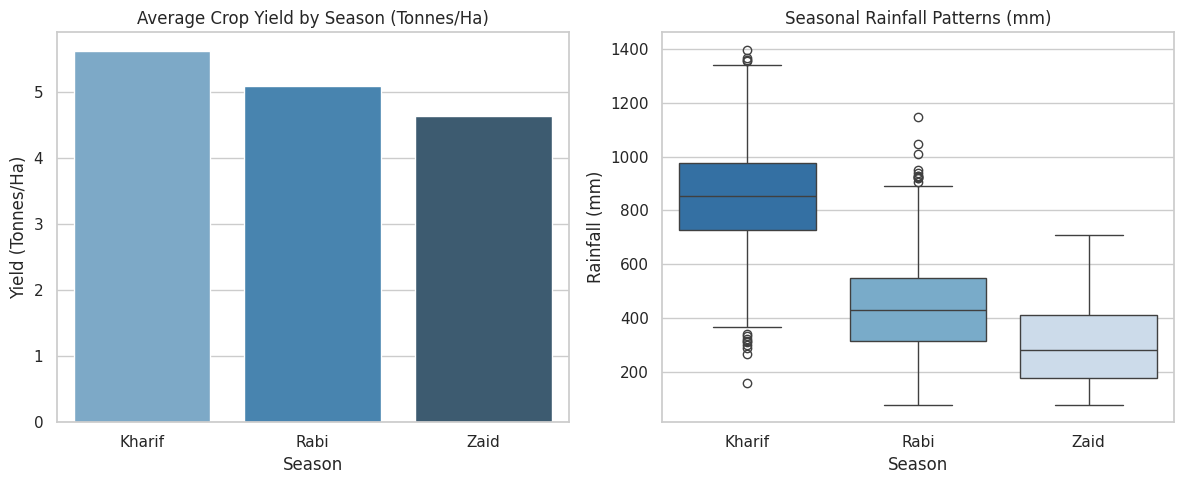

        Yield_Tonnes_Ha  Rainfall_mm
Season                              
Kharif         5.630616   852.112676
Rabi           5.094917   435.937062
Zaid           4.637340   299.123232


In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha',
    palette='Blues_d',
    errorbar=None,
    estimator='mean',
)
plt.title('Average Crop Yield by Season (Tonnes/Ha)')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Season', y='Rainfall_mm', palette='Blues_r')
plt.title('Seasonal Rainfall Patterns (mm)')
plt.xlabel('Season')
plt.ylabel('Rainfall (mm)')

plt.tight_layout()
plt.savefig('slide6_yield_results.png', dpi=300)
plt.show()

print(df.groupby('Season')[['Yield_Tonnes_Ha', 'Rainfall_mm']].mean())

## Results (Slide 7): Economic Performance & Farm Profitability
**Core Findings:**
- Kharif operations achieve substantial financial surplus, generating an average net profit of ~₹1,78,915 per farm.
- Rabi delivers steady, positive operating margins (~₹87,689 per farm).
- Zaid crops face an average net deficit (-₹24,805 per farm). Because input and cultivation expenses remain high (~₹5.44 Lakhs) while yields fall, farming in the dry season without precision irrigation leads to financial loss.

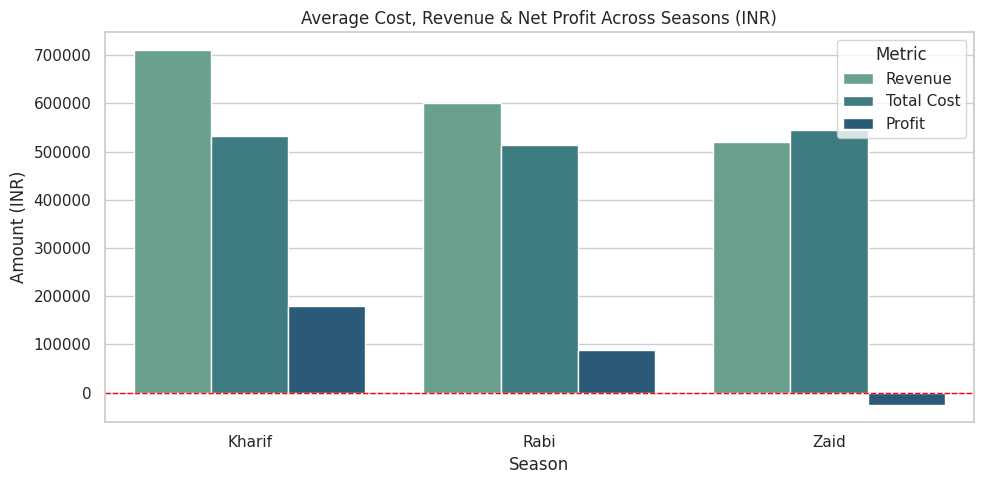

   Season    Revenue_INR  Total_Cost_INR     Profit_INR
0  Kharif  710719.055649   531804.408094  178914.647555
1    Rabi  601526.048556   513836.578365   87689.470191
2    Zaid  519171.904040   543976.728956  -24804.824916


In [ ]:
plt.figure(figsize=(10, 5))

econ_df = (
    df.groupby('Season')[['Revenue_INR', 'Total_Cost_INR', 'Profit_INR']]
    .mean()
    .reset_index()
)
econ_melted = pd.melt(
    econ_df,
    id_vars=['Season'],
    value_vars=['Revenue_INR', 'Total_Cost_INR', 'Profit_INR'],
    var_name='Financial_Metric',
    value_name='Amount_INR',
)

econ_melted['Financial_Metric'] = (
    econ_melted['Financial_Metric']
    .str.replace('_INR', '')
    .str.replace('_', ' ')
)

sns.barplot(
    data=econ_melted,
    x='Season',
    y='Amount_INR',
    hue='Financial_Metric',
    palette='crest',
)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Average Cost, Revenue & Net Profit Across Seasons (INR)')
plt.xlabel('Season')
plt.ylabel('Amount (INR)')
plt.legend(title='Metric')

plt.tight_layout()
plt.savefig('slide7_economic_results.png', dpi=300)
plt.show()

print(econ_df)

## Results (Slide 8): Resource Usage & Irrigation Efficiency
**Core Findings:**
- Drip and Sprinkler irrigation systems deliver significantly higher water productivity ($t / 1000\text{ m}^3$) than traditional flood irrigation methods.
- Water efficiency reaches its highest point during Kharif (~5.89 t/1000m³) and drops to ~4.41 t/1000m³ in Zaid due to evaporation and transmission losses.

/tmp/ipykernel_8944/1071249379.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_8944/1071249379.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


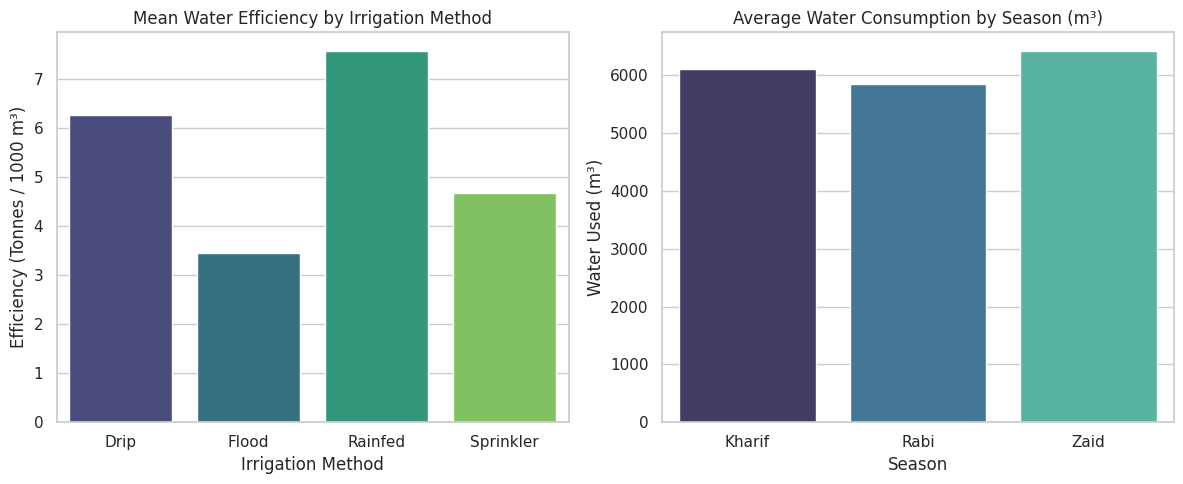

Irrigation_Method
Drip         6.267129
Flood        3.438853
Rainfed      7.563784
Sprinkler    4.669805
Name: Water_Efficiency_t_per_1000m3, dtype: float64
Season
Kharif    6102.201237
Rabi      5846.987093
Zaid      6419.893939
Name: Water_Used_m3, dtype: float64


In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(
    data=df,
    x='Irrigation_Method',
    y='Water_Efficiency_t_per_1000m3',
    palette='viridis',
    errorbar=None,
    estimator='mean',
)
plt.title('Mean Water Efficiency by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Efficiency (Tonnes / 1000 m³)')

plt.subplot(1, 2, 2)
sns.barplot(
    data=df,
    x='Season',
    y='Water_Used_m3',
    palette='mako',
    errorbar=None,
    estimator='mean',
)
plt.title('Average Water Consumption by Season (m³)')
plt.xlabel('Season')
plt.ylabel('Water Used (m³)')

plt.tight_layout()
plt.savefig('slide8_resource_efficiency.png', dpi=300)
plt.show()

print(df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].mean())
print(df.groupby('Season')['Water_Used_m3'].mean())

## Results (Slide 9): Environmental Risk & Feature Correlation
**Core Findings:**
- High temperature coupled with increased humidity drives elevated pest and disease risk scores.
- Applying chemical fertilizers and pesticides above balanced thresholds shows diminishing returns on yield while driving up cultivation costs, directly decreasing net profit.

/tmp/ipykernel_8944/1800012954.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


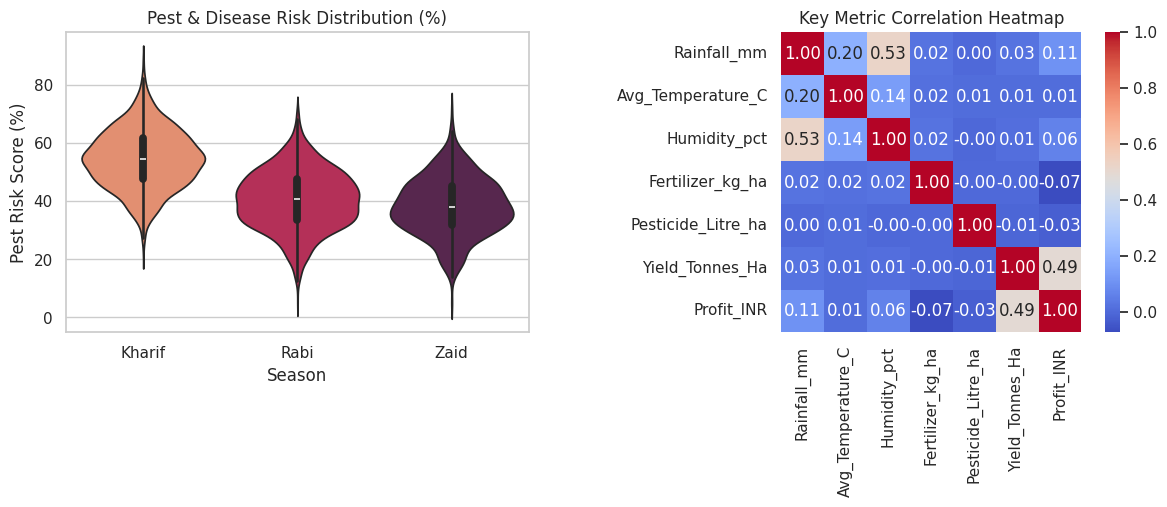

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.violinplot(
    data=df, x='Season', y='Disease_Pest_Risk_pct', palette='rocket_r'
)
plt.title('Pest & Disease Risk Distribution (%)')
plt.xlabel('Season')
plt.ylabel('Pest Risk Score (%)')

plt.subplot(1, 2, 2)
corr_cols = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Yield_Tonnes_Ha',
    'Profit_INR',
]
sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    cbar=True,
    square=True,
)
plt.title('Key Metric Correlation Heatmap')

plt.tight_layout()
plt.savefig('slide9_risk_and_correlation.png', dpi=300)
plt.show()

## Results (Slide 10): Crop-Specific Performance Across Seasons
**Core Findings:**
- High-moisture crops such as Rice, Sugarcane, and Cotton achieve their maximum production during Kharif.
- Wheat and Pulses exhibit stable yields during Rabi, providing consistent economic baseline returns.
- Attempting high-water crops during Zaid without micro-irrigation accounts for the primary drop in overall seasonal productivity.

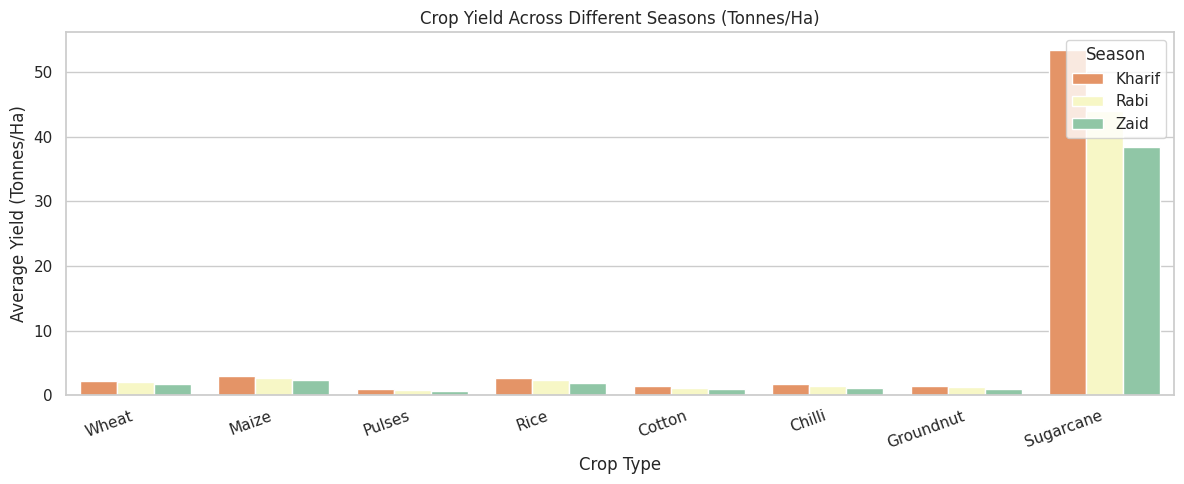

Season        Kharif       Rabi       Zaid
Crop                                      
Chilli      1.731676   1.462822   1.179062
Cotton      1.373140   1.192985   0.951848
Groundnut   1.483834   1.222994   1.037778
Maize       2.966410   2.617489   2.297262
Pulses      1.036063   0.872019   0.652258
Rice        2.709268   2.334526   1.900490
Sugarcane  53.459120  43.963953  38.423922
Wheat       2.255788   2.059515   1.748588


In [ ]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=df,
    x='Crop',
    y='Yield_Tonnes_Ha',
    hue='Season',
    palette='Spectral',
    errorbar=None,
)
plt.title('Crop Yield Across Different Seasons (Tonnes/Ha)')
plt.xlabel('Crop Type')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Season', loc='upper right')

plt.tight_layout()
plt.savefig('slide10_crop_suitability.png', dpi=300)
plt.show()

print(
    df.pivot_table(
        index='Crop', columns='Season', values='Yield_Tonnes_Ha', aggfunc='mean'
    )
)

## Future Scope
- **Machine Learning Integration:** Train supervised regression models (Random Forest, XGBoost) to forecast farm-level yield and crop prices prior to sowing.
- **Dynamic Decision Support:** Deploy an IoT and real-time weather advisory pipeline for automated, sensor-based micro-irrigation scheduling.
- **Spatial GIS Mapping:** Extend analysis with geospatial heatmaps to evaluate district-level drought susceptibility and targeted input allocation.